## Personal Data Analysis: Spotify Listening History

In [19]:
import utils
import matplotlib.pyplot as plt
from scipy import stats

## 1. Load the Data

In [20]:
df = utils.load_data("spotifydata.csv")
df.head(10)

,artist,track,ms_played,date,year,month,day,minutes_played
timestamp,,,,,,,,
2025-02-05 19:47:00,Taylor Swift,The Smallest Man Who Ever Lived,48186,2025-02-05,2025,2,5,8.031000
2025-02-05 20:00:00,America,Ventura Highway,211680,2025-02-05,2025,2,5,35.280000
2025-02-05 20:03:00,Looking Glass,Brandy (You're a Fine Girl),186826,2025-02-05,2025,2,5,31.137667
2025-02-05 20:08:00,A Flock Of Seagulls,I Ran (So Far Away),308933,2025-02-05,2025,2,5,51.488833
2025-02-05 20:11:00,Matthew Wilder,Break My Stride,184480,2025-02-05,2025,2,5,30.746667
2025-02-05 20:16:00,Tears For Fears,"Head Over Heels - Dave Bascombe 7"" N.Mix",257315,2025-02-05,2025,2,5,42.885833
2025-02-05 20:20:00,Carly Simon,You're So Vain,258411,2025-02-05,2025,2,5,43.068500
2025-02-05 20:23:00,Seals and Crofts,Summer Breeze,205480,2025-02-05,2025,2,5,34.246667
2025-02-05 20:26:00,Glen Campbell,Southern Nights,180026,2025-02-05,2025,2,5,30.004333


## 2. Clean the Data

In [21]:
df = utils.clean_data(df)
df.to_csv("spotifydata.csv")
df.head(10)

,artist,track,ms_played,date,year,month,day,minutes_played
timestamp,,,,,,,,
2025-02-05 19:47:00,Taylor Swift,The Smallest Man Who Ever Lived,48186,2025-02-05,2025,2,5,8.031000
2025-02-05 20:00:00,America,Ventura Highway,211680,2025-02-05,2025,2,5,35.280000
2025-02-05 20:03:00,Looking Glass,Brandy (You're a Fine Girl),186826,2025-02-05,2025,2,5,31.137667
2025-02-05 20:08:00,A Flock Of Seagulls,I Ran (So Far Away),308933,2025-02-05,2025,2,5,51.488833
2025-02-05 20:11:00,Matthew Wilder,Break My Stride,184480,2025-02-05,2025,2,5,30.746667
2025-02-05 20:16:00,Tears For Fears,"Head Over Heels - Dave Bascombe 7"" N.Mix",257315,2025-02-05,2025,2,5,42.885833
2025-02-05 20:20:00,Carly Simon,You're So Vain,258411,2025-02-05,2025,2,5,43.068500
2025-02-05 20:23:00,Seals and Crofts,Summer Breeze,205480,2025-02-05,2025,2,5,34.246667
2025-02-05 20:26:00,Glen Campbell,Southern Nights,180026,2025-02-05,2025,2,5,30.004333


## 3. Identify Top Artists

In [22]:
top = utils.top_artists(df)

for i, (artist, count) in enumerate(top.items(), 1):
    print(f"{i}. {artist} ({count} plays)")

1. Hozier (281 plays)
2. Taylor Swift (194 plays)
3. Noah Kahan (183 plays)
4. Sabrina Carpenter (86 plays)
5. Fleetwood Mac (59 plays)


## 4. Visualize the Data

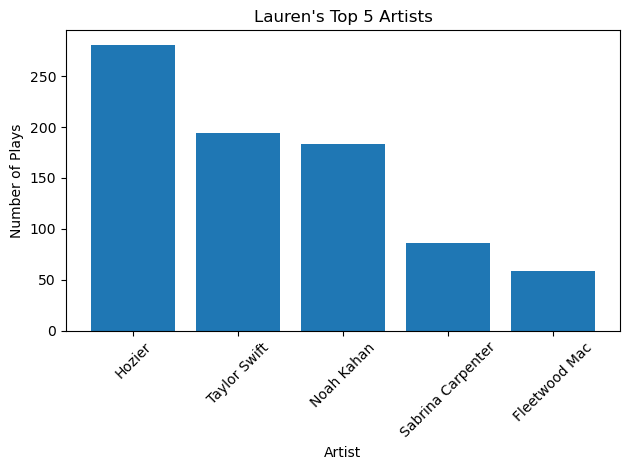

In [23]:
# top artists bar chart
plt.figure()
plt.bar(top.index, top.values)
plt.title("Lauren's Top 5 Artists")
plt.xlabel("Artist")
plt.ylabel("Number of Plays")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:

# filter to top artists
top_names = top.index
df_top = df[df['artist'].isin(top_names)]

In [25]:
# group by month + artist
monthly = df_top.groupby(['month', 'artist']).size().unstack(fill_value=0)

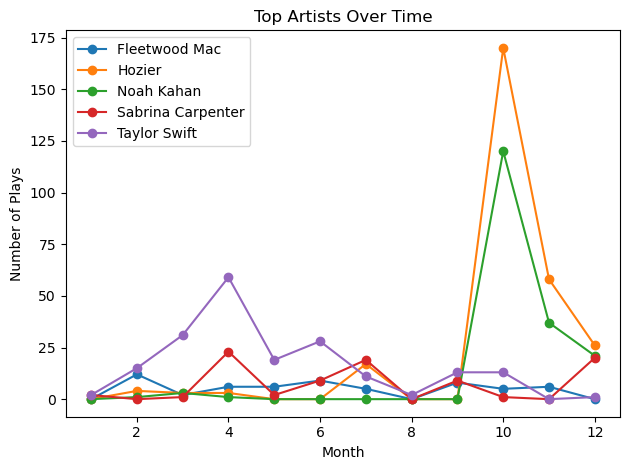

In [26]:
# plot top artists over time
plt.figure()

for artist in monthly.columns:
    plt.plot(monthly.index, monthly[artist], marker='o', label=artist)

plt.title("Top Artists Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Plays")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Hypothesis Test

Null Hypothesis: Listening to my top artist is consistent across months

Alternative Hypothesis: It varies across months

In [27]:
# pick most frequent artist
top_artist = df['artist'].value_counts().idxmax()

artist_data = df[df['artist'] == top_artist]

groups = [
    artist_data[artist_data['month'] == m]['minutes_played']
    for m in artist_data['month'].unique()
]

f_stat, p_val = stats.f_oneway(*groups)

print("Top Artist:", top_artist)
print("F-stat:", f_stat)
print("p-value:", p_val)


Top Artist: Hozier
F-stat: 2.95818218017091
p-value: 0.008168391254264665


## Conclusion

The p-value is (insert here)

If p < 0.05:
- Reject the null hypothesis
- My listening to my top artist varies significantly across months

If p > 0.05:
- Fail to reject the null hypothesis
- There is not significant evidence to suggest that my listening changes across months
